# Lagrange Interpolation Functions for the Finite Element Method

This notebook demonstrates the Lagrange family of interpolation functions for 1-D finite elements using simple Python code.

For a polynomial of degree $p$,

$$
\boxed{\text{Number of nodes} = p+1}
$$

The general Lagrange interpolation function is

$$
\boxed{
N_i(\xi)=
\prod_{\substack{j=1\\j\neq i}}^{p+1}
\frac{\xi-\xi_j}{\xi_i-\xi_j}
}
$$

The defining interpolation property is

$$
\boxed{N_i(\xi_j)=\delta_{ij}}
$$

which means

$$
N_i(\xi_j)=
\begin{cases}
1, & i=j \\
0, & i\neq j
\end{cases}
$$

The finite-element approximation is

$$
\boxed{
u^h(\xi)=\sum_{i=1}^{p+1}N_i(\xi)u_i
}
$$


## 1. Import libraries


In [15]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.animation import FuncAnimation
from IPython.display import HTML


## 2. General Lagrange interpolation function

The same Python function works for first-, second-, third-, and higher-degree interpolation functions.

$$
N_i(\xi)=
\prod_{j\neq i}
\frac{\xi-\xi_j}{\xi_i-\xi_j}
$$


In [16]:
def lagrange_basis(x, nodes, i):
    # Start the product with 1
    N = np.ones_like(x, dtype=float)

    # Multiply all terms except j = i
    for j in range(len(nodes)):
        if j != i:
            N = N * (x - nodes[j]) / (nodes[i] - nodes[j])

    return N


# 3. First-degree Lagrange polynomial

For $p=1$, there are two nodes.

$$
\xi_1=-1,
\qquad
\xi_2=1
$$

The interpolation functions are

$$
N_1(\xi)=\frac{1-\xi}{2},
\qquad
N_2(\xi)=\frac{1+\xi}{2}
$$

and the finite-element approximation is

$$
u^h(\xi)=N_1u_1+N_2u_2
$$


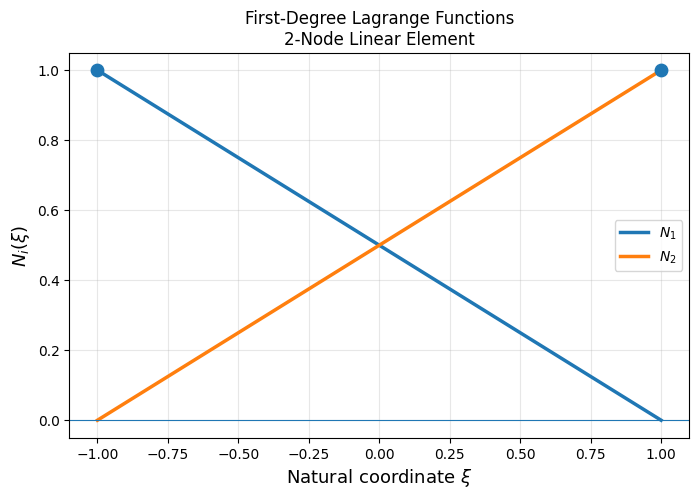

In [17]:
p = 1

nodes = np.linspace(-1, 1, p + 1)
xi = np.linspace(-1, 1, 500)

plt.figure(figsize=(8, 5))

for i in range(len(nodes)):
    N = lagrange_basis(xi, nodes, i)
    plt.plot(xi, N, linewidth=2.5, label=f"$N_{i+1}$")

plt.scatter(nodes, np.ones(len(nodes)), s=80, zorder=5)
plt.axhline(0, linewidth=0.8)

plt.xlabel(r"Natural coordinate $\xi$", fontsize=13)
plt.ylabel(r"$N_i(\xi)$", fontsize=13)

plt.title("First-Degree Lagrange Functions\n2-Node Linear Element")

plt.legend()
plt.grid(alpha=0.3)
plt.show()


# 4. Second-degree Lagrange polynomial

For $p=2$, there are three nodes.

$$
\xi_1=-1,
\qquad
\xi_2=0,
\qquad
\xi_3=1
$$

The quadratic interpolation functions are

$$
N_1(\xi)=\frac{\xi(\xi-1)}{2}
$$

$$
N_2(\xi)=1-\xi^2
$$

$$
N_3(\xi)=\frac{\xi(\xi+1)}{2}
$$

The approximation is

$$
u^h(\xi)=N_1u_1+N_2u_2+N_3u_3
$$


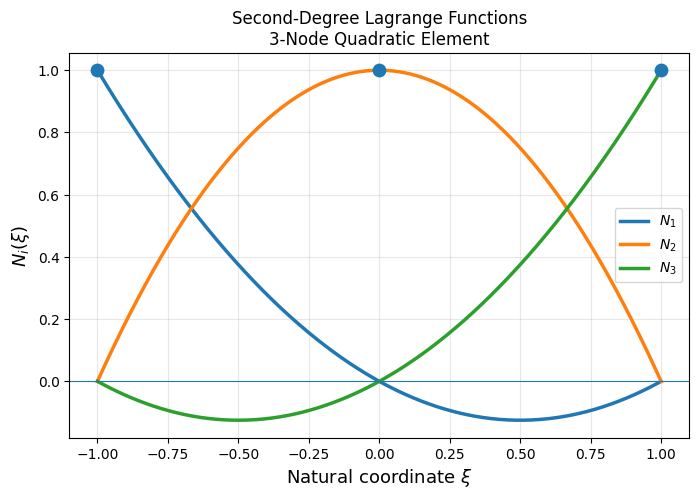

In [18]:
p = 2

nodes = np.linspace(-1, 1, p + 1)
xi = np.linspace(-1, 1, 500)

plt.figure(figsize=(8, 5))

for i in range(len(nodes)):
    N = lagrange_basis(xi, nodes, i)
    plt.plot(xi, N, linewidth=2.5, label=f"$N_{i+1}$")

plt.scatter(nodes, np.ones(len(nodes)), s=80, zorder=5)
plt.axhline(0, linewidth=0.8)

plt.xlabel(r"Natural coordinate $\xi$", fontsize=13)
plt.ylabel(r"$N_i(\xi)$", fontsize=13)

plt.title("Second-Degree Lagrange Functions\n3-Node Quadratic Element")

plt.legend()
plt.grid(alpha=0.3)
plt.show()


# 5. Third-degree Lagrange polynomial

For $p=3$, there are four equally spaced nodes.

$$
\xi_1=-1,
\qquad
\xi_2=-\frac{1}{3},
\qquad
\xi_3=\frac{1}{3},
\qquad
\xi_4=1
$$

The approximation is

$$
u^h(\xi)=\sum_{i=1}^{4}N_i(\xi)u_i
$$


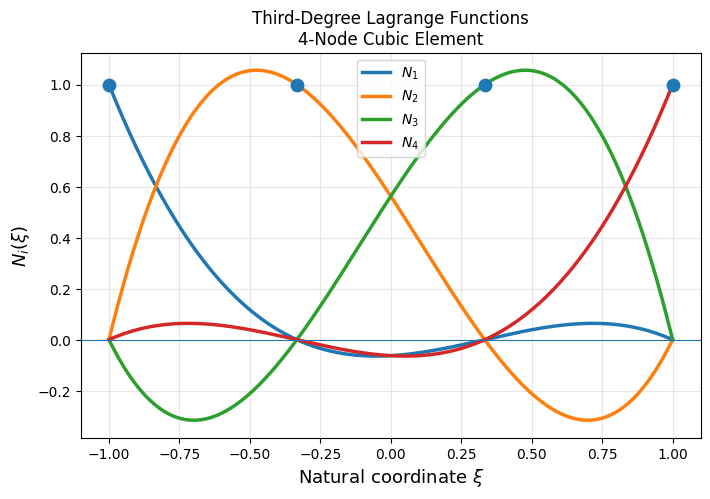

In [19]:
p = 3

nodes = np.linspace(-1, 1, p + 1)
xi = np.linspace(-1, 1, 500)

plt.figure(figsize=(8, 5))

for i in range(len(nodes)):
    N = lagrange_basis(xi, nodes, i)
    plt.plot(xi, N, linewidth=2.5, label=f"$N_{i+1}$")

plt.scatter(nodes, np.ones(len(nodes)), s=80, zorder=5)
plt.axhline(0, linewidth=0.8)

plt.xlabel(r"Natural coordinate $\xi$", fontsize=13)
plt.ylabel(r"$N_i(\xi)$", fontsize=13)

plt.title("Third-Degree Lagrange Functions\n4-Node Cubic Element")

plt.legend()
plt.grid(alpha=0.3)
plt.show()


# 6. General $n^{\mathrm{th}}$-degree Lagrange element

For any polynomial degree $p$,

$$
\boxed{
u^h(\xi)=
\sum_{i=1}^{p+1}N_i(\xi)u_i
}
$$

with

$$
\boxed{
N_i(\xi)=
\prod_{\substack{j=1\\j\neq i}}^{p+1}
\frac{\xi-\xi_j}{\xi_i-\xi_j}
}
$$

Change the value of `p` below to visualize any polynomial order.


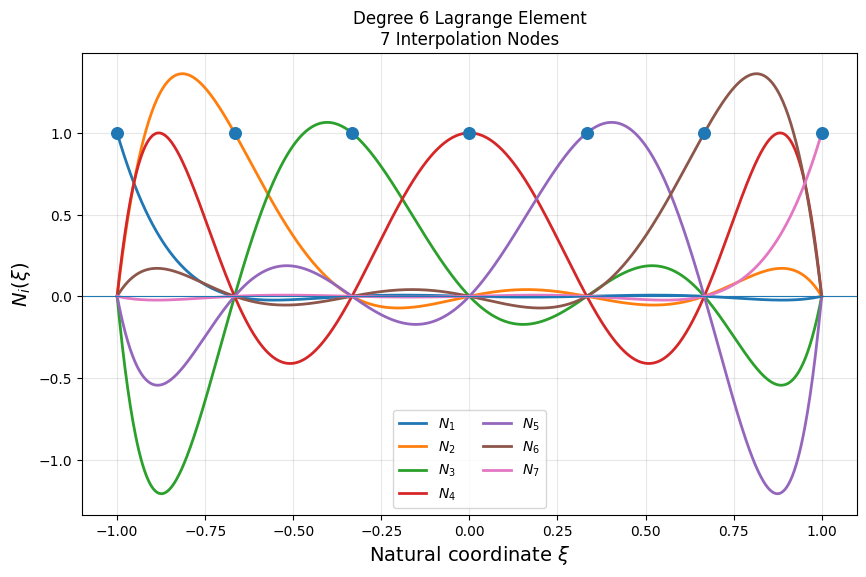

In [20]:
p = 6   # Change this value during class

nodes = np.linspace(-1, 1, p + 1)
xi = np.linspace(-1, 1, 800)

plt.figure(figsize=(10, 6))

for i in range(len(nodes)):
    N = lagrange_basis(xi, nodes, i)
    plt.plot(xi, N, linewidth=2, label=f"$N_{i+1}$")

plt.scatter(nodes, np.ones(len(nodes)), s=70, zorder=5)
plt.axhline(0, linewidth=0.8)

plt.xlabel(r"Natural coordinate $\xi$", fontsize=14)
plt.ylabel(r"$N_i(\xi)$", fontsize=14)

plt.title(f"Degree {p} Lagrange Element\n{p+1} Interpolation Nodes")

plt.legend(ncol=2)
plt.grid(alpha=0.3)
plt.show()


# 7. Verify the interpolation property

The Lagrange family satisfies

$$
\boxed{N_i(\xi_j)=\delta_{ij}}
$$

Therefore, the matrix $[N_i(\xi_j)]$ should be the identity matrix.


In [21]:
p = 3

nodes = np.linspace(-1, 1, p + 1)

N_matrix = np.zeros((p + 1, p + 1))

for i in range(p + 1):
    N_matrix[i, :] = lagrange_basis(nodes, nodes, i)

print("Interpolation matrix N_i(xi_j):\n")
print(np.round(N_matrix, 5))


Interpolation matrix N_i(xi_j):

[[ 1. -0.  0. -0.]
 [ 0.  1. -0.  0.]
 [-0.  0.  1. -0.]
 [ 0. -0.  0.  1.]]


# 8. Partition of unity

Lagrange interpolation functions satisfy

$$
\boxed{
\sum_{i=1}^{p+1}N_i(\xi)=1
}
$$

This is the partition of unity property.


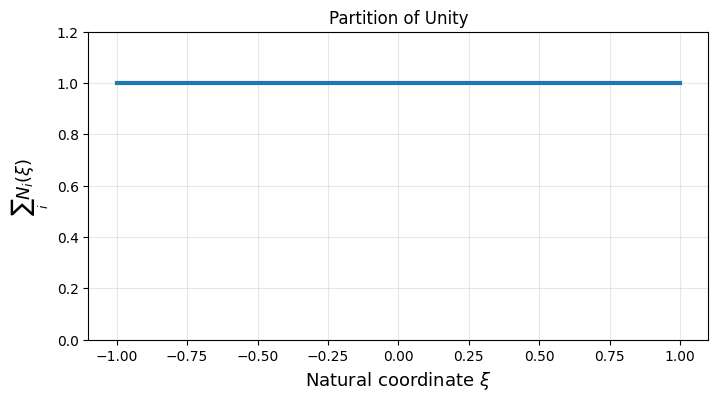

In [22]:
p = 4

nodes = np.linspace(-1, 1, p + 1)
xi = np.linspace(-1, 1, 500)

sum_N = np.zeros_like(xi)

for i in range(p + 1):
    sum_N += lagrange_basis(xi, nodes, i)

plt.figure(figsize=(8, 4))

plt.plot(xi, sum_N, linewidth=3)

plt.xlabel(r"Natural coordinate $\xi$", fontsize=13)
plt.ylabel(r"$\sum_i N_i(\xi)$", fontsize=13)

plt.title("Partition of Unity")

plt.ylim(0, 1.2)
plt.grid(alpha=0.3)
plt.show()


# 9. Non-uniform quadratic element

The interior node does **not** have to be at the center.

Instead of

$$
[-1,\;0,\;1]
$$

we can choose

$$
[-1,\;\alpha,\;1]
$$

with, for example,

$$
\alpha=-0.4
$$

The Lagrange interpolation property still holds:

$$
N_i(\xi_j)=\delta_{ij}
$$


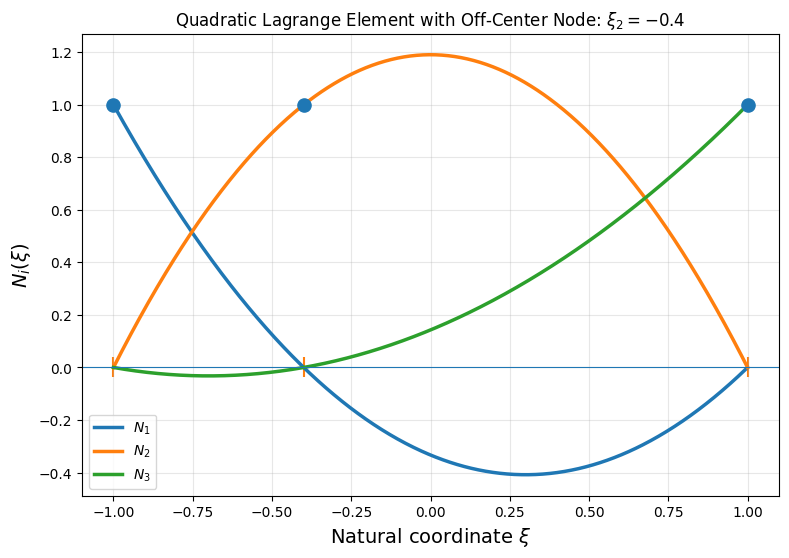

In [23]:
alpha = -0.40

nodes = np.array([-1.0, alpha, 1.0])
xi = np.linspace(-1, 1, 800)

plt.figure(figsize=(9, 6))

for i in range(len(nodes)):
    N = lagrange_basis(xi, nodes, i)
    plt.plot(xi, N, linewidth=2.5, label=f"$N_{i+1}$")

# Show node locations at N = 1
plt.scatter(nodes, np.ones(len(nodes)), s=90, zorder=5)

# Also show the node positions along the xi-axis
plt.scatter(nodes, np.zeros(len(nodes)), marker="|", s=200)

plt.axhline(0, linewidth=0.8)

plt.xlabel(r"Natural coordinate $\xi$", fontsize=14)
plt.ylabel(r"$N_i(\xi)$", fontsize=14)

plt.title(rf"Quadratic Lagrange Element with Off-Center Node: $\xi_2={alpha}$")

plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Verify the non-uniform interpolation property

Even after moving the interior node,

$$
\boxed{
[N_i(\xi_j)] = [I]
}
$$

should still hold.


In [24]:
N_matrix = np.zeros((len(nodes), len(nodes)))

for i in range(len(nodes)):
    N_matrix[i, :] = lagrange_basis(nodes, nodes, i)

print("N_i evaluated at the non-uniform nodes:\n")
print(np.round(N_matrix, 5))


N_i evaluated at the non-uniform nodes:

[[ 1. -0.  0.]
 [ 0.  1. -0.]
 [-0.  0.  1.]]


# 10. Uniform versus non-uniform quadratic nodes

Uniform quadratic nodes:

$$
[-1,\;0,\;1]
$$

Non-uniform quadratic nodes:

$$
[-1,\;-0.4,\;1]
$$

Both sets produce valid quadratic Lagrange interpolation functions.


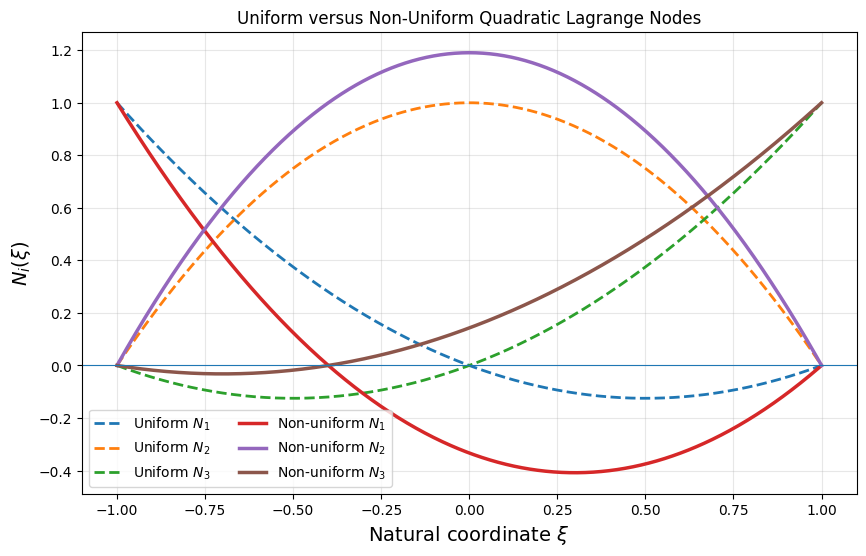

In [25]:
xi = np.linspace(-1, 1, 800)

uniform_nodes = np.array([-1.0, 0.0, 1.0])
nonuniform_nodes = np.array([-1.0, -0.40, 1.0])

plt.figure(figsize=(10, 6))

# Uniform-node Lagrange functions
for i in range(3):

    N = lagrange_basis(xi, uniform_nodes, i)

    plt.plot(
        xi,
        N,
        "--",
        linewidth=2,
        label=f"Uniform $N_{i+1}$"
    )

# Non-uniform-node Lagrange functions
for i in range(3):

    N = lagrange_basis(xi, nonuniform_nodes, i)

    plt.plot(
        xi,
        N,
        linewidth=2.5,
        label=f"Non-uniform $N_{i+1}$"
    )

plt.axhline(0, linewidth=0.8)

plt.xlabel(r"Natural coordinate $\xi$", fontsize=14)
plt.ylabel(r"$N_i(\xi)$", fontsize=14)

plt.title("Uniform versus Non-Uniform Quadratic Lagrange Nodes")

plt.legend(ncol=2)
plt.grid(alpha=0.3)
plt.show()


# 11. General non-uniform nodes

The Lagrange formula does not require equally spaced nodes.

For example, a cubic element may use

$$
\xi_1=-1,
\qquad
\xi_2=-0.50,
\qquad
\xi_3=0.20,
\qquad
\xi_4=1
$$

The polynomial degree is still

$$
p=3
$$

because there are four interpolation nodes.


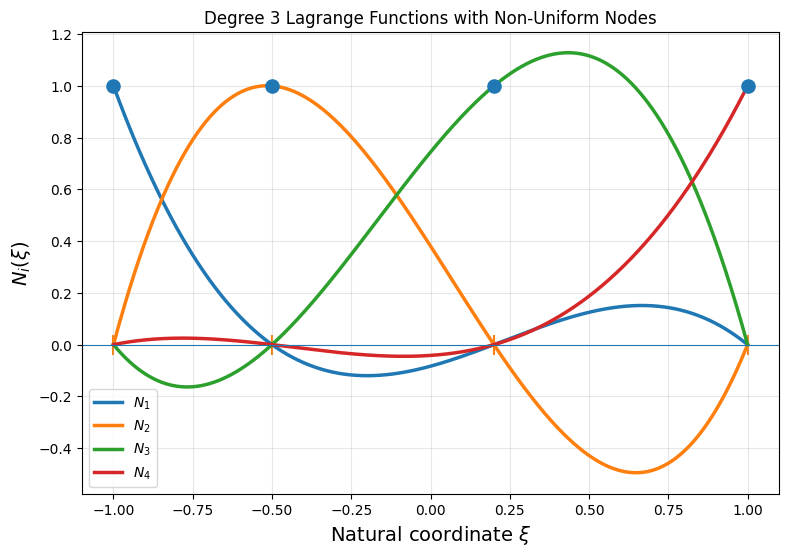

In [26]:
# Specify any non-uniform node locations
nodes = np.array([
    -1.00,
    -0.50,
     0.20,
     1.00
])

p = len(nodes) - 1

xi = np.linspace(-1, 1, 800)

plt.figure(figsize=(9, 6))

for i in range(len(nodes)):

    N = lagrange_basis(xi, nodes, i)

    plt.plot(
        xi,
        N,
        linewidth=2.5,
        label=f"$N_{i+1}$"
    )

plt.scatter(nodes, np.ones(len(nodes)), s=90, zorder=5)
plt.scatter(nodes, np.zeros(len(nodes)), marker="|", s=200)

plt.axhline(0, linewidth=0.8)

plt.xlabel(r"Natural coordinate $\xi$", fontsize=14)
plt.ylabel(r"$N_i(\xi)$", fontsize=14)

plt.title(f"Degree {p} Lagrange Functions with Non-Uniform Nodes")

plt.legend()
plt.grid(alpha=0.3)
plt.show()


# 12. Animation: polynomial degree $1\rightarrow n$

The animation shows

$$
p=1
\rightarrow
p=2
\rightarrow
p=3
\rightarrow
\cdots
\rightarrow
p=n
$$

and illustrates

$$
\boxed{
p\text{-th degree}
\Rightarrow
p+1\text{ nodes}
\Rightarrow
p+1\text{ Lagrange functions}
}
$$


In [ ]:
maximum_degree = 8

xi = np.linspace(-1, 1, 800)

fig, ax = plt.subplots(figsize=(10, 6))

def update(p):

    ax.clear()

    nodes = np.linspace(-1, 1, p + 1)

    for i in range(p + 1):

        N = lagrange_basis(xi, nodes, i)

        ax.plot(
            xi,
            N,
            linewidth=2,
            label=f"$N_{i+1}$"
        )

    ax.scatter(nodes, np.ones(p + 1), s=70, zorder=5)

    ax.axhline(0, linewidth=0.8)

    ax.set_xlim(-1.05, 1.05)
    ax.set_ylim(-2, 2)

    ax.set_xlabel(r"Natural coordinate $\xi$", fontsize=13)
    ax.set_ylabel(r"$N_i(\xi)$", fontsize=13)

    ax.set_title(
        f"Lagrange Interpolation Functions\n"
        f"Polynomial Degree = {p}, Nodes = {p+1}"
    )

    ax.legend(ncol=2, fontsize=9, loc="upper center")
    ax.grid(alpha=0.3)

animation = FuncAnimation(
    fig,
    update,
    frames=range(1, maximum_degree + 1),
    interval=1500,
    repeat=True
)

plt.close()

HTML(animation.to_jshtml())


# 13. Animation: move the interior node of a quadratic element

For a quadratic element,

$$
\xi_1=-1,
\qquad
\xi_2=\alpha,
\qquad
\xi_3=1
$$

The animation below moves the interior node $\alpha$ from left to right.

The important observation is that the interpolation property remains valid for every admissible location of $\alpha$.


In [ ]:
xi = np.linspace(-1, 1, 800)

# Interior-node locations used in the animation
alpha_values = np.linspace(-0.8, 0.8, 25)

fig, ax = plt.subplots(figsize=(10, 6))

def move_middle_node(alpha):

    ax.clear()

    nodes = np.array([-1.0, alpha, 1.0])

    for i in range(3):

        N = lagrange_basis(xi, nodes, i)

        ax.plot(
            xi,
            N,
            linewidth=2.5,
            label=f"$N_{i+1}$"
        )

    ax.scatter(nodes, np.ones(3), s=90, zorder=5)
    ax.scatter(nodes, np.zeros(3), marker="|", s=200)

    ax.axhline(0, linewidth=0.8)

    ax.set_xlim(-1.05, 1.05)
    ax.set_ylim(-1.5, 2.5)

    ax.set_xlabel(r"Natural coordinate $\xi$", fontsize=13)
    ax.set_ylabel(r"$N_i(\xi)$", fontsize=13)

    ax.set_title(
        rf"Quadratic Lagrange Element: Moving Interior Node, $\alpha={alpha:.2f}$"
    )

    ax.legend()
    ax.grid(alpha=0.3)

animation_middle_node = FuncAnimation(
    fig,
    move_middle_node,
    frames=alpha_values,
    interval=250,
    repeat=True
)

plt.close()

HTML(animation_middle_node.to_jshtml())


# Summary

### Polynomial degree and number of nodes

$$
\boxed{
p\text{-th degree polynomial}
\Rightarrow
p+1\text{ interpolation nodes}
}
$$

### Lagrange interpolation property

$$
\boxed{
N_i(\xi_j)=\delta_{ij}
}
$$

### Finite-element interpolation

$$
\boxed{
u^h(\xi)=
\sum_{i=1}^{p+1}N_i(\xi)u_i
}
$$

### Partition of unity

$$
\boxed{
\sum_{i=1}^{p+1}N_i(\xi)=1
}
$$

